In [1]:
import numpy as np

from matplotlib import pyplot as plt
import pandas as pd
from astroML.datasets import fetch_sdss_specgals
import plotly.express as px

In [2]:
data = fetch_sdss_specgals()
df = pd.DataFrame(data)

pd.set_option('display.float_format', lambda x: '%.9f' % x)

In [3]:
print(data.shape, df.shape)

(661598,) (661598, 43)


In [4]:
# 1. Calculate the Color Indices
# For galaxies in SDSS, you should always use the 'modelMag' columns
df['u-g'] = df['modelMag_u'] - df['modelMag_g']
df['g-r'] = df['modelMag_g'] - df['modelMag_r']
df['r-i'] = df['modelMag_r'] - df['modelMag_i']
df['i-z'] = df['modelMag_i'] - df['modelMag_z']

model_mag_error = 0.25
# 2. Clean the Data
# We are using your specific error columns to drop noisy observations
df = df[
    # Ensure the magnitude errors are low (less than 0.2 is a good benchmark)
    (df['modelMagErr_u'] < model_mag_error) &
    (df['modelMagErr_g'] < model_mag_error) &
    (df['modelMagErr_r'] < model_mag_error) &
    (df['modelMagErr_i'] < model_mag_error) &
    (df['modelMagErr_z'] < model_mag_error) &
    
    # Ignore the local universe blob (z < 0.05) to see the higher redshift track better
    (df['z'] > 0.275)
]

len(df)

1481

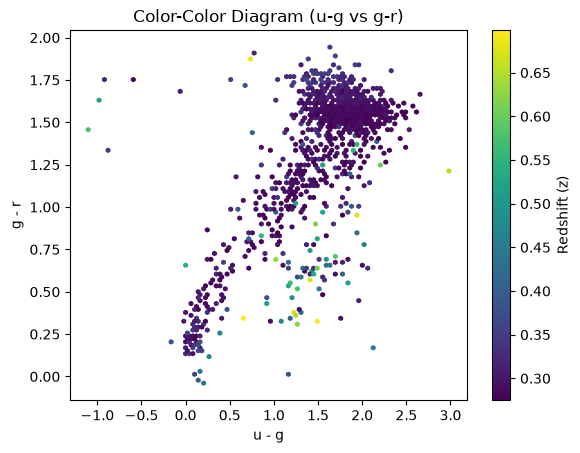

In [31]:
hb = plt.hexbin(df['u-g'], df['g-r'], C = df['z'])

# 2. Add labels to the x and y axes
plt.xlabel('u - g')
plt.ylabel('g - r')

# 3. Add a title to the top of the plot
plt.title('Color-Color Diagram (u-g vs g-r)')

# 4. Add a colorbar and label it
cb = plt.colorbar(hb)
cb.set_label('Redshift (z)')

# 5. Display the plot
plt.show()

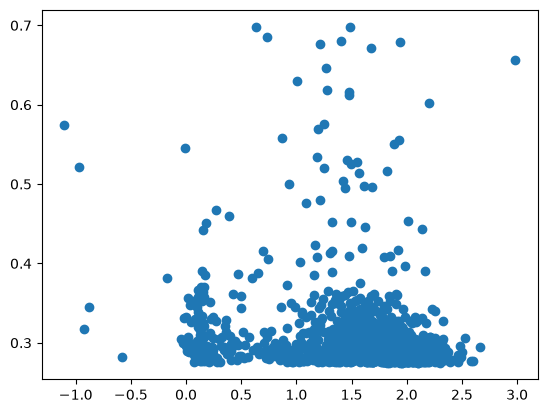

In [12]:
x = df['u-g']
y = df['z']

plt.scatter(x,y)

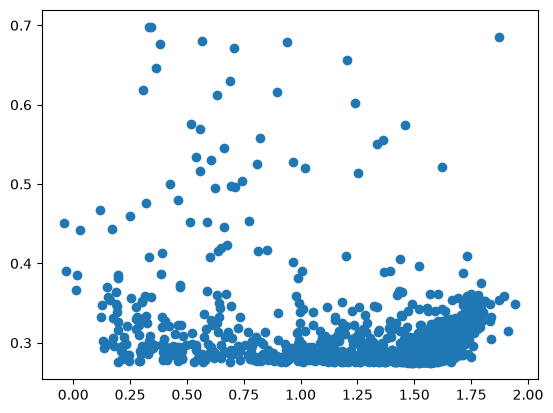

In [13]:
x = df['g-r']
y = df['z']

plt.scatter(x,y)

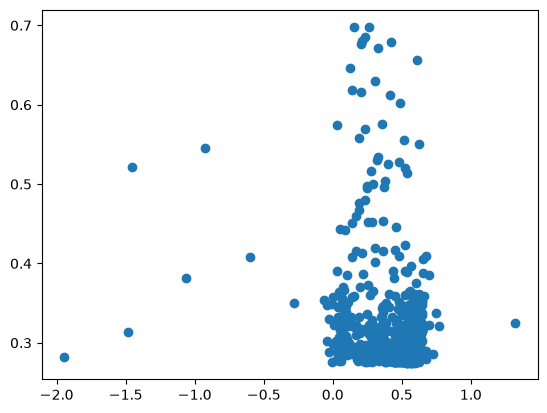

In [14]:
x = df['r-i']
y = df['z']

plt.scatter(x, y)

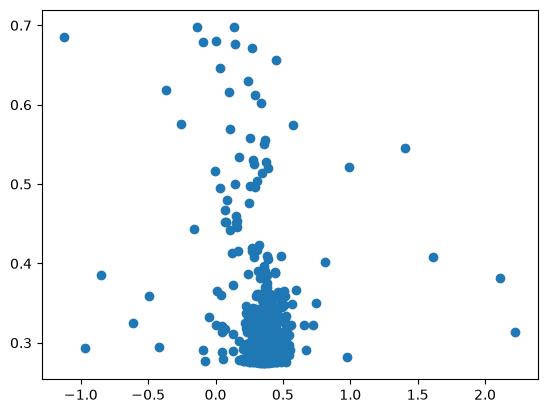

In [16]:
plt.scatter(df['i-z'], df['z'])

In [37]:
# 3. Create the 3D Scatter Plot (using the subsampled df_plot)
fig = px.scatter_3d(
    df, 
    x=df['u-g'], 
    y=df['g-r'], 
    z=df['r-i'],
    color=df['z'],
    color_continuous_scale='Plasma',
    title='The Correlation: 3D Redshift Track (Subsampled)'
)

# Refine the marker size so it is easier to see the track
fig.update_traces(marker=dict(size=4, opacity=0.8))

# Explicitly make the plot larger and reduce outer margins to fill the cell
fig.update_layout(
    width=800,          # Set width in pixels
    height=600,          # Set height in pixels
)
# Display the interactive plot
fig.show()
len(df)

1481